## 1.1 Import Libraries

In [2]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image

## 1.2 Define Dataset Path

In [3]:
DATA_DIR = Path("../1. Data/mvtec_anomaly_detection")

## 1.3 Dataset Categories

The MVTec Anomaly Detection dataset contains multiple industrial object and texture
categories. Each category includes normal training images and test images containing
both normal and anomalous samples.

In this section, we inspect the available product categories and verify the dataset
directory structure.

In [4]:
categories = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print(f"Number of categories: {len(categories)}")
print(categories)

Number of categories: 15
['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


## 1.4 Directory Structure

Each MVTec category follows a similar structure:

- `train/good/`: defect-free training images
- `test/good/`: defect-free test images
- `test/<defect_type>/`: anomalous test images
- `ground_truth/<defect_type>/`: pixel-level segmentation masks for anomalous images

An important characteristic of MVTec AD is that the training set contains only
normal samples. This makes the problem fundamentally different from standard
supervised binary classification.

In [5]:
sample_category = categories[0]
category_path = DATA_DIR / sample_category

print(f"Category: {sample_category}")

for root, dirs, files in os.walk(category_path):
    level = root.replace(str(category_path), "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{Path(root).name}/")

    subindent = "    " * (level + 1)

    for file in files[:3]:
        print(f"{subindent}{file}")

    if len(files) > 3:
        print(f"{subindent}... ({len(files)} files)")

Category: bottle
bottle/
    readme.txt
    license.txt
    test/
        broken_small/
            002.png
            016.png
            017.png
            ... (22 files)
        broken_large/
            002.png
            016.png
            017.png
            ... (20 files)
        good/
            002.png
            016.png
            017.png
            ... (20 files)
        contamination/
            002.png
            016.png
            017.png
            ... (21 files)
    ground_truth/
        broken_small/
            000_mask.png
            001_mask.png
            017_mask.png
            ... (22 files)
        broken_large/
            000_mask.png
            001_mask.png
            017_mask.png
            ... (20 files)
        contamination/
            000_mask.png
            001_mask.png
            017_mask.png
            ... (21 files)
    train/
        good/
            176.png
            162.png
            189.png
            ... (209 files)


## 1.5 Image Counts by Category

We next calculate the number of training and test images for each product category.

Because MVTec AD is designed for unsupervised anomaly detection, all training
images belong to the `good` class, while anomalies appear only in the test set.

In [6]:
dataset_summary = []

for category in categories:
    
    category_path = DATA_DIR / category

    train_good_path = category_path / "train" / "good"
    test_path = category_path / "test"

    train_good_count = len(list(train_good_path.glob("*.png")))

    test_good_count = 0
    test_anomaly_count = 0
    defect_types = []

    for defect_folder in test_path.iterdir():
        
        if not defect_folder.is_dir():
            continue

        image_count = len(list(defect_folder.glob("*.png")))

        if defect_folder.name == "good":
            test_good_count += image_count
        else:
            test_anomaly_count += image_count
            defect_types.append(defect_folder.name)

    dataset_summary.append({
        "category": category,
        "train_good": train_good_count,
        "test_good": test_good_count,
        "test_anomaly": test_anomaly_count,
        "total_test": test_good_count + test_anomaly_count,
        "num_defect_types": len(defect_types)
    })


summary_df = pd.DataFrame(dataset_summary)

summary_df

,category,train_good,test_good,test_anomaly,total_test,num_defect_types
0,bottle,209,20,63,83,3
1,cable,224,58,92,150,8
2,capsule,219,23,109,132,5
3,carpet,280,28,89,117,5
4,grid,264,21,57,78,5
5,hazelnut,391,40,70,110,4
6,leather,245,32,92,124,5
7,metal_nut,220,22,93,115,4
8,pill,267,26,141,167,7
9,screw,320,41,119,160,5


## 1.6 Dataset Summary Statistics

In [7]:
summary_df.sum(numeric_only=True)

train_good          3629
test_good            467
test_anomaly        1258
total_test          1725
num_defect_types      73
dtype: int64

In [8]:
print("Total training images:", summary_df["train_good"].sum())
print("Total normal test images:", summary_df["test_good"].sum())
print("Total anomalous test images:", summary_df["test_anomaly"].sum())
print("Total test images:", summary_df["total_test"].sum())

Total training images: 3629
Total normal test images: 467
Total anomalous test images: 1258
Total test images: 1725


## 1.7 Normal vs. Anomalous Test Distribution

Although the training dataset contains only normal images, the test dataset contains
both normal and defective samples.

Understanding this distribution is important because evaluation metrics such as
ROC-AUC and precision-recall may be affected by class imbalance.

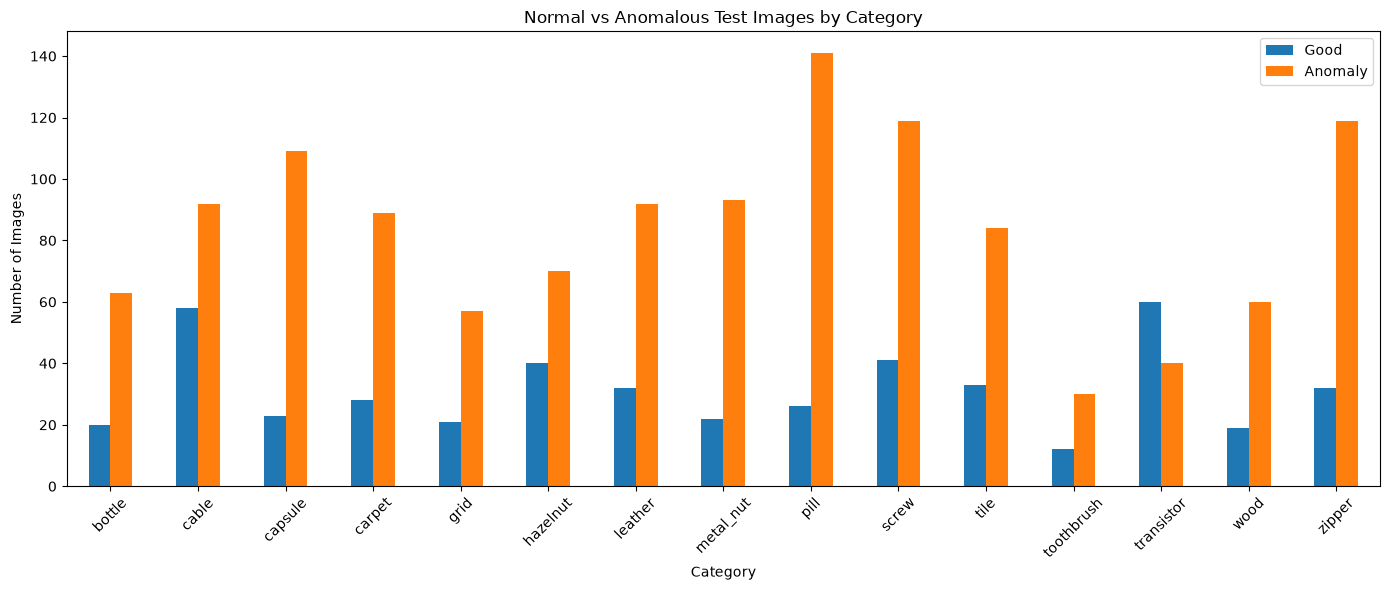

In [9]:
plot_df = summary_df.set_index("category")[
    ["test_good", "test_anomaly"]
]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Normal vs Anomalous Test Images by Category")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(["Good", "Anomaly"])
plt.tight_layout()
plt.show()

## 1.8 Defect Types

Each industrial category contains different types of defects. For example, defects
may include scratches, cracks, contamination, holes, deformation, or missing
components.

Examining the available defect classes helps us understand the diversity of
anomalies that the model will need to detect.

In [10]:
defect_summary = []

for category in categories:

    test_path = DATA_DIR / category / "test"

    for defect_folder in sorted(test_path.iterdir()):

        if not defect_folder.is_dir():
            continue

        defect_type = defect_folder.name

        image_count = len(list(defect_folder.glob("*.png")))

        defect_summary.append({
            "category": category,
            "defect_type": defect_type,
            "count": image_count
        })


defect_df = pd.DataFrame(defect_summary)

defect_df

,category,defect_type,count
0,bottle,broken_large,20
1,bottle,broken_small,22
2,bottle,contamination,21
3,bottle,good,20
4,cable,bent_wire,13
...,...,...,...
83,zipper,fabric_interior,16
84,zipper,good,32
85,zipper,rough,17
86,zipper,split_teeth,18


To exclude `good`,

In [11]:
anomaly_defect_df = defect_df[
    defect_df["defect_type"] != "good"
].reset_index(drop=True)

anomaly_defect_df

,category,defect_type,count
0,bottle,broken_large,20
1,bottle,broken_small,22
2,bottle,contamination,21
3,cable,bent_wire,13
4,cable,cable_swap,12
...,...,...,...
68,zipper,fabric_border,17
69,zipper,fabric_interior,16
70,zipper,rough,17
71,zipper,split_teeth,18


## 1.9 Image Dimensions

Image resolution is an important consideration for computer vision modeling.

The original MVTec images are relatively high resolution and their dimensions can
differ across categories. Later, during preprocessing, images will likely need to
be resized to a consistent resolution before being passed into the neural network.

Here we inspect the original image dimensions without modifying the data.

In [12]:
image_dimensions = []

for category in categories:

    train_path = DATA_DIR / category / "train" / "good"

    for image_path in train_path.glob("*.png"):

        with Image.open(image_path) as img:
            width, height = img.size

        image_dimensions.append({
            "category": category,
            "width": width,
            "height": height
        })


dimensions_df = pd.DataFrame(image_dimensions)

dimensions_df.head()

,category,width,height
0,bottle,900,900
1,bottle,900,900
2,bottle,900,900
3,bottle,900,900
4,bottle,900,900


In [13]:
dimensions_df.groupby("category").agg(
    num_images=("width", "count"),
    min_width=("width", "min"),
    max_width=("width", "max"),
    min_height=("height", "min"),
    max_height=("height", "max"),
    unique_widths=("width", "nunique"),
    unique_heights=("height", "nunique")
)

,num_images,min_width,max_width,min_height,max_height,unique_widths,unique_heights
category,,,,,,,
bottle,209,900,900,900,900,1,1
cable,224,1024,1024,1024,1024,1,1
capsule,219,1000,1000,1000,1000,1,1
carpet,280,1024,1024,1024,1024,1,1
grid,264,1024,1024,1024,1024,1,1
hazelnut,391,1024,1024,1024,1024,1,1
leather,245,1024,1024,1024,1024,1,1
metal_nut,220,700,700,700,700,1,1
pill,267,800,800,800,800,1,1


## 1.10 Normal Training Image Samples

The training dataset contains only defect-free (`good`) images.

Visual inspection of these images helps us understand what the model must learn
as the normal appearance of each industrial product.

In [16]:
def show_normal_samples(category, n=5):

    image_paths = sorted(
        (DATA_DIR / category / "train" / "good").glob("*.png")
    )

    n = min(n, len(image_paths))

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4 * n, 4)
    )

    if n == 1:
        axes = [axes]

    for ax, image_path in zip(axes, image_paths[:n]):

        image = Image.open(image_path)

        ax.imshow(image)
        ax.axis("off")
        ax.set_title(image_path.name)

    plt.suptitle(f"{category} — Normal Training Images")
    plt.tight_layout()
    plt.show()

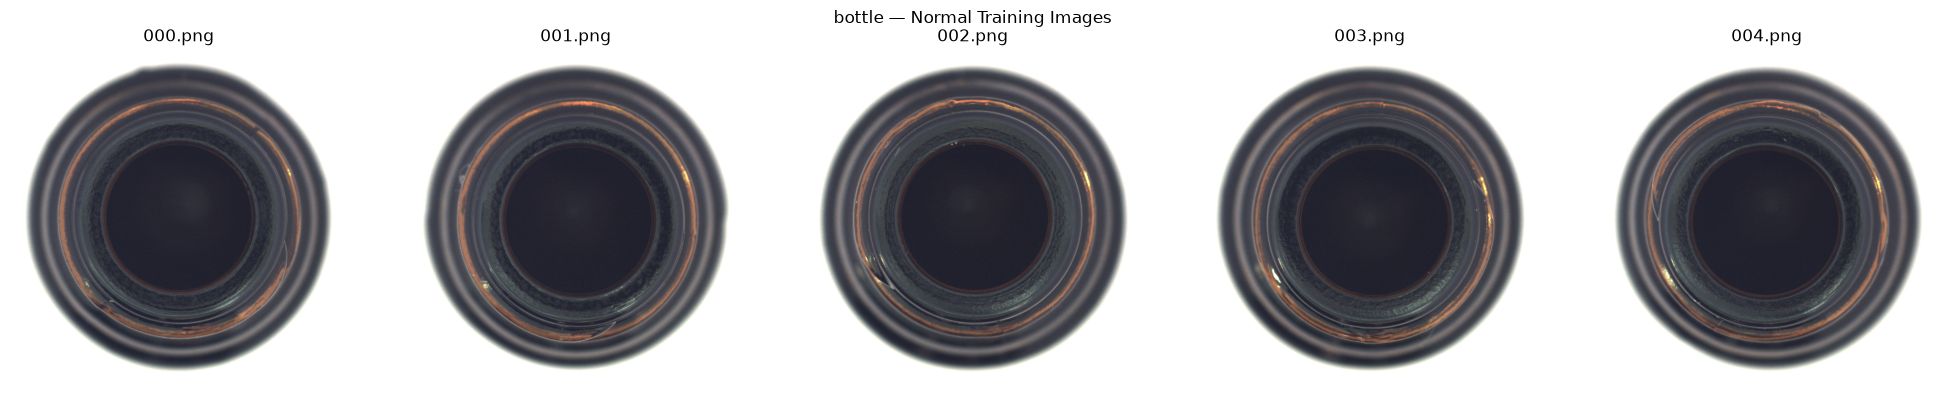

In [17]:
show_normal_samples("bottle", n=5)

## 1.11 Visualize Normal Samples Across All Categories

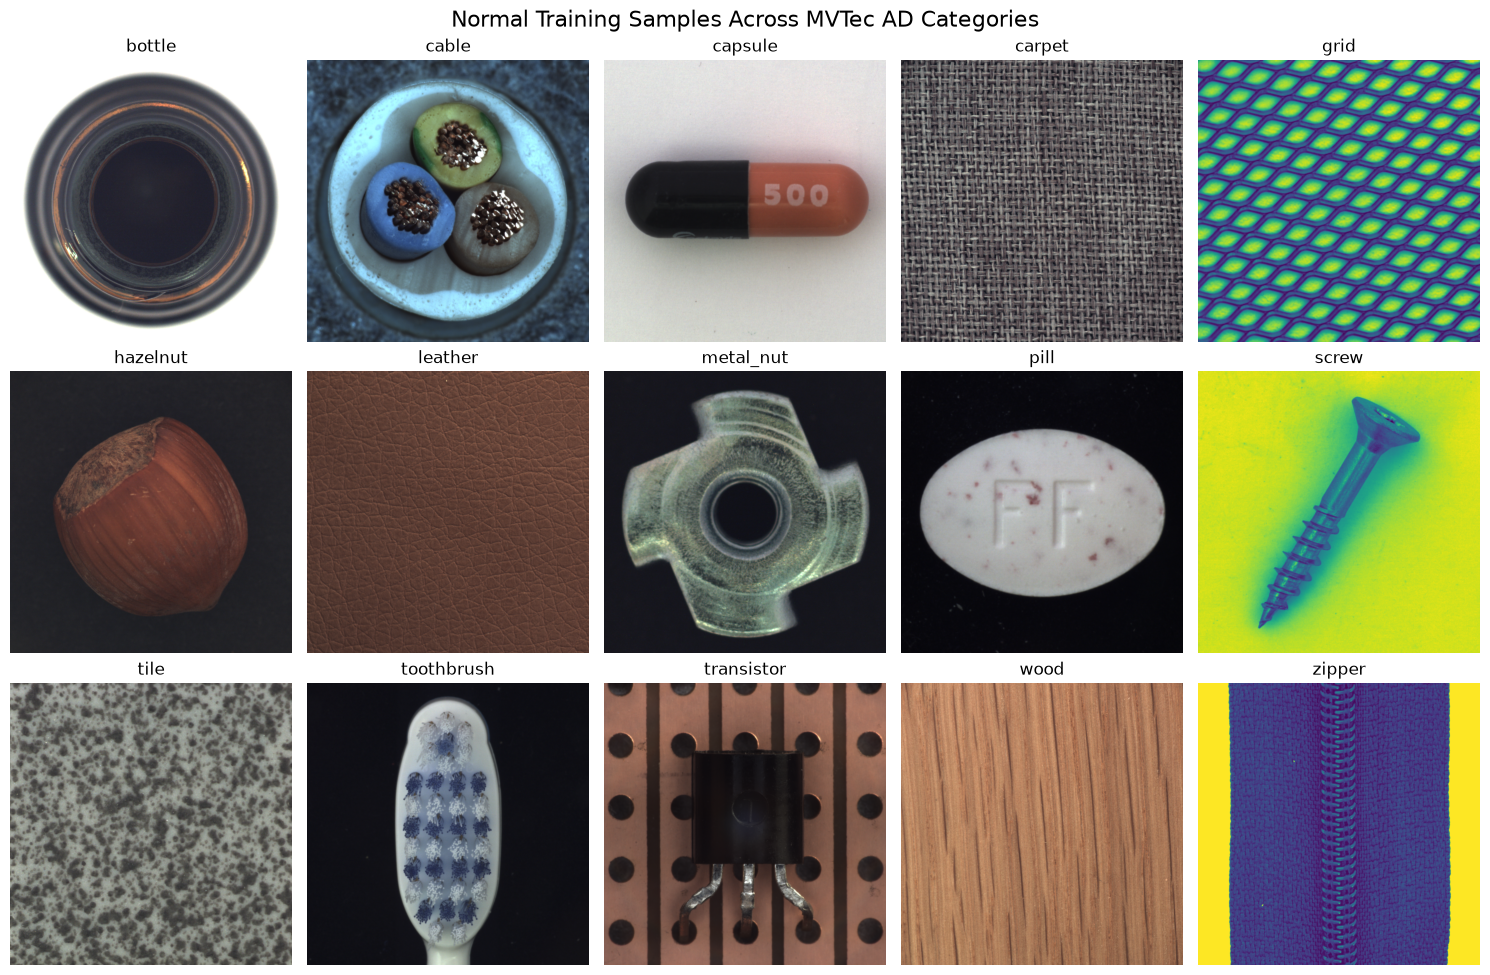

In [18]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, category in zip(axes, categories):

    image_path = next(
        (DATA_DIR / category / "train" / "good").glob("*.png")
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(category)

plt.suptitle(
    "Normal Training Samples Across MVTec AD Categories",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 1.12 Anomalous Test Samples

Unlike the training set, the test set contains multiple defect types.

Visualizing anomalous samples allows us to understand the range of defect sizes,
locations, textures, and appearances that the anomaly detection model must identify.

In [19]:
def show_anomaly_samples(category, n=5):

    test_path = DATA_DIR / category / "test"

    defect_folders = [
        folder
        for folder in test_path.iterdir()
        if folder.is_dir() and folder.name != "good"
    ]

    image_paths = []

    for folder in defect_folders:
        image_paths.extend(list(folder.glob("*.png")))

    image_paths = sorted(image_paths)

    n = min(n, len(image_paths))

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4 * n, 4)
    )

    if n == 1:
        axes = [axes]

    for ax, image_path in zip(axes, image_paths[:n]):

        image = Image.open(image_path)

        ax.imshow(image)
        ax.axis("off")
        ax.set_title(image_path.parent.name)

    plt.suptitle(f"{category} — Anomalous Test Images")

    plt.tight_layout()
    plt.show()

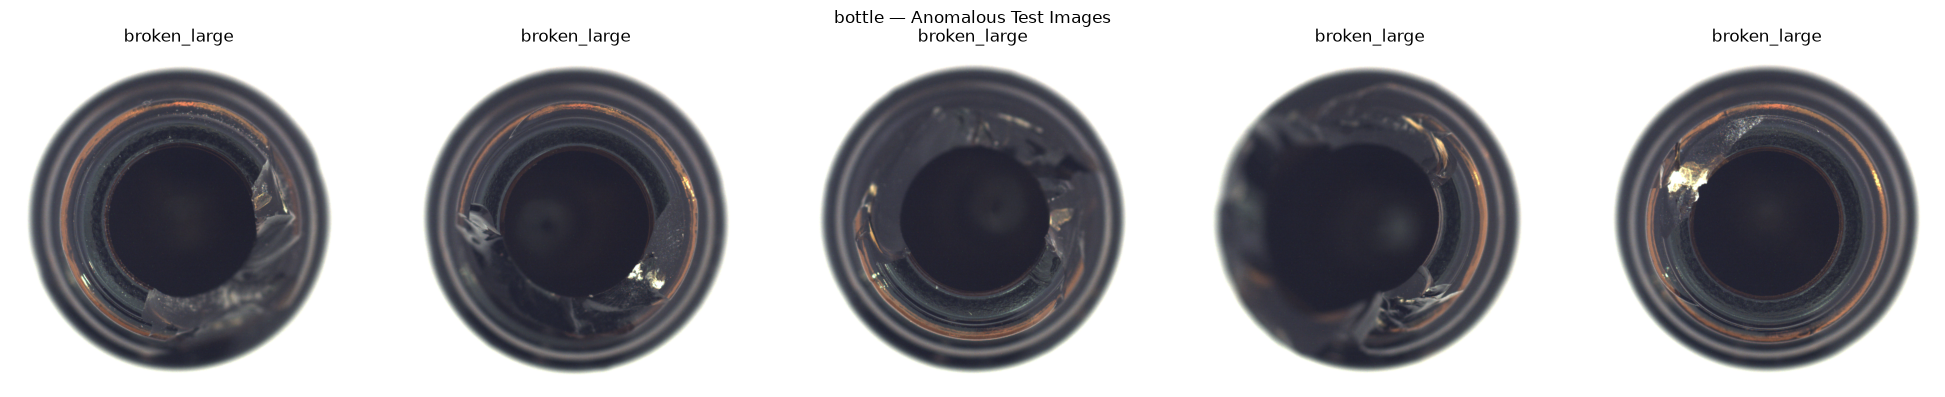

In [20]:
show_anomaly_samples("bottle", n=5)

## 1.13 Compare Normal vs Anomalous Images

In [21]:
def compare_normal_anomaly(category):

    normal_path = next(
        (DATA_DIR / category / "test" / "good").glob("*.png")
    )

    defect_folders = [
        folder
        for folder in (DATA_DIR / category / "test").iterdir()
        if folder.is_dir() and folder.name != "good"
    ]

    anomaly_path = next(
        defect_folders[0].glob("*.png")
    )

    normal_image = Image.open(normal_path)
    anomaly_image = Image.open(anomaly_path)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    axes[0].imshow(normal_image)
    axes[0].set_title("Normal")
    axes[0].axis("off")

    axes[1].imshow(anomaly_image)
    axes[1].set_title(
        f"Anomaly: {anomaly_path.parent.name}"
    )
    axes[1].axis("off")

    plt.suptitle(category)

    plt.tight_layout()
    plt.show()

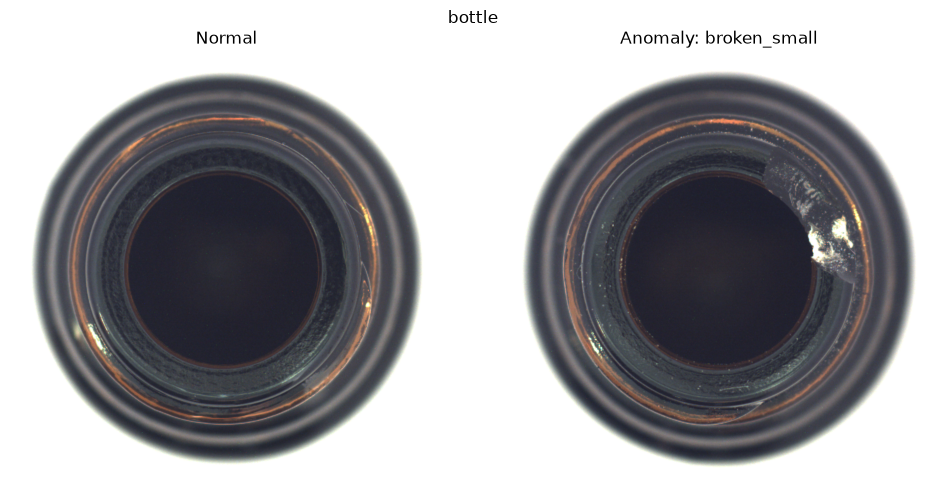

In [22]:
compare_normal_anomaly("bottle")

## 1.14 Ground-Truth Segmentation Masks

For anomalous test images, MVTec AD provides pixel-level ground-truth masks.

White pixels in the mask indicate defective regions, while black pixels represent
normal regions.

These masks allow the project to evaluate two related tasks:

1. **Image-level anomaly detection** — determine whether an image is normal or anomalous.
2. **Pixel-level anomaly localization** — determine where the defect occurs within the image.

In [23]:
def show_anomaly_with_mask(category, defect_type=None):

    test_path = DATA_DIR / category / "test"

    if defect_type is None:

        defect_folders = [
            folder
            for folder in test_path.iterdir()
            if folder.is_dir() and folder.name != "good"
        ]

        defect_folder = sorted(defect_folders)[0]

    else:

        defect_folder = test_path / defect_type

    image_path = sorted(
        defect_folder.glob("*.png")
    )[0]

    defect_type = defect_folder.name

    mask_path = (
        DATA_DIR
        / category
        / "ground_truth"
        / defect_type
        / f"{image_path.stem}_mask.png"
    )

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    axes[0].imshow(image)
    axes[0].set_title(
        f"Anomalous Image\n{defect_type}"
    )
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    plt.suptitle(category)

    plt.tight_layout()
    plt.show()

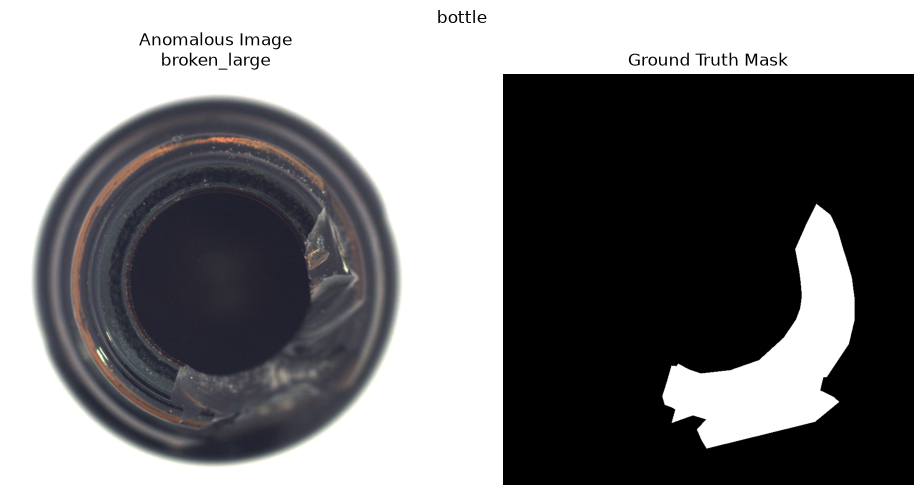

In [24]:
show_anomaly_with_mask("bottle")

## 1.15 Overlay Ground Truth on Defective Image

In [25]:
def show_mask_overlay(category, defect_type=None):

    test_path = DATA_DIR / category / "test"

    if defect_type is None:

        defect_folders = [
            folder
            for folder in test_path.iterdir()
            if folder.is_dir() and folder.name != "good"
        ]

        defect_folder = sorted(defect_folders)[0]

    else:

        defect_folder = test_path / defect_type

    image_path = sorted(
        defect_folder.glob("*.png")
    )[0]

    defect_type = defect_folder.name

    mask_path = (
        DATA_DIR
        / category
        / "ground_truth"
        / defect_type
        / f"{image_path.stem}_mask.png"
    )

    image = np.array(
        Image.open(image_path)
    )

    mask = np.array(
        Image.open(mask_path)
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(
        mask,
        cmap="Reds",
        alpha=0.4
    )

    axes[2].set_title("Defect Overlay")
    axes[2].axis("off")

    plt.suptitle(
        f"{category} — {defect_type}"
    )

    plt.tight_layout()
    plt.show()

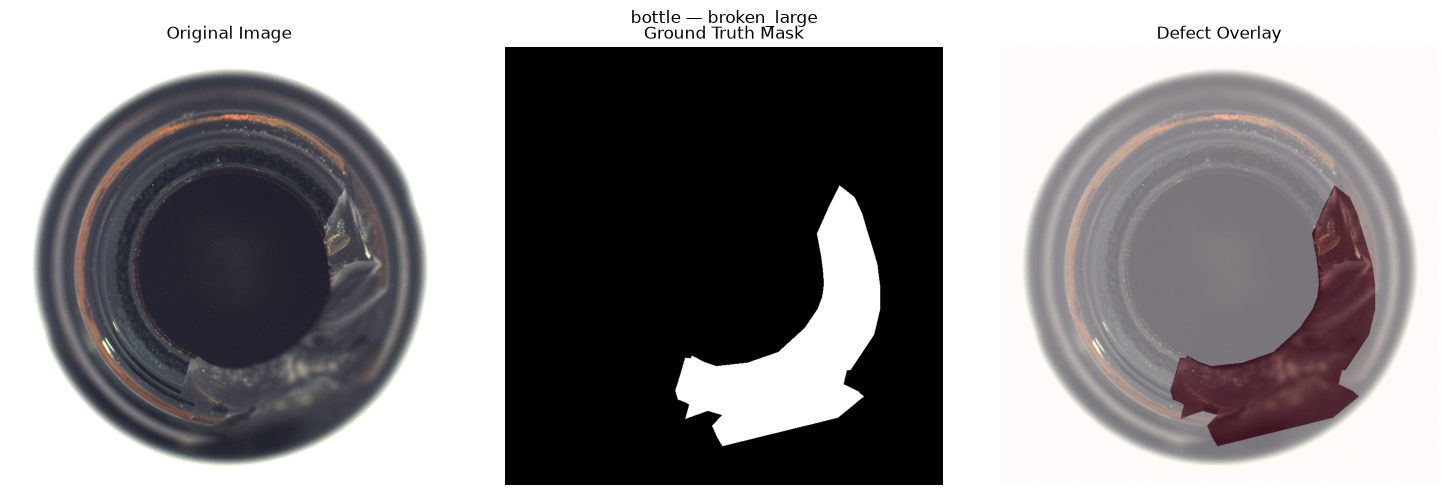

In [26]:
show_mask_overlay("bottle")

## 1.16 Defect Area Analysis

Industrial defects can vary significantly in size. Some anomalies occupy a large
portion of the product, while others affect only a very small number of pixels.

Small defects can be substantially harder to detect, particularly after image
resizing or feature downsampling in convolutional neural networks.

We therefore examine the proportion of each image occupied by the annotated defect.

In [27]:
defect_areas = []

for category in categories:

    ground_truth_path = DATA_DIR / category / "ground_truth"

    if not ground_truth_path.exists():
        continue

    for defect_folder in ground_truth_path.iterdir():

        if not defect_folder.is_dir():
            continue

        for mask_path in defect_folder.glob("*.png"):

            mask = np.array(
                Image.open(mask_path).convert("L")
            )

            defect_pixels = np.sum(mask > 0)
            total_pixels = mask.size

            defect_ratio = defect_pixels / total_pixels

            defect_areas.append({
                "category": category,
                "defect_type": defect_folder.name,
                "defect_ratio": defect_ratio
            })


defect_area_df = pd.DataFrame(defect_areas)

defect_area_df.head()

,category,defect_type,defect_ratio
0,bottle,broken_small,0.008847
1,bottle,broken_small,0.014773
2,bottle,broken_small,0.025165
3,bottle,broken_small,0.020467
4,bottle,broken_small,0.045898


## 1.17 Defect Area Statistics

In [28]:
defect_area_df.groupby("category")["defect_ratio"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean")

,count,mean,median,min,max
category,,,,,
screw,119,0.003355,0.002879,0.000985,0.010108
leather,92,0.008742,0.004615,0.000886,0.068594
grid,57,0.009452,0.006015,0.001884,0.035815
capsule,109,0.011089,0.004295,0.000371,0.080787
carpet,89,0.021064,0.014757,0.001650,0.080171
toothbrush,30,0.021410,0.010778,0.002381,0.129764
zipper,119,0.026241,0.023544,0.001592,0.118310
hazelnut,70,0.033546,0.016158,0.002329,0.276586
pill,141,0.039773,0.010327,0.000505,0.410036


<Figure size 1200x600 with 0 Axes>

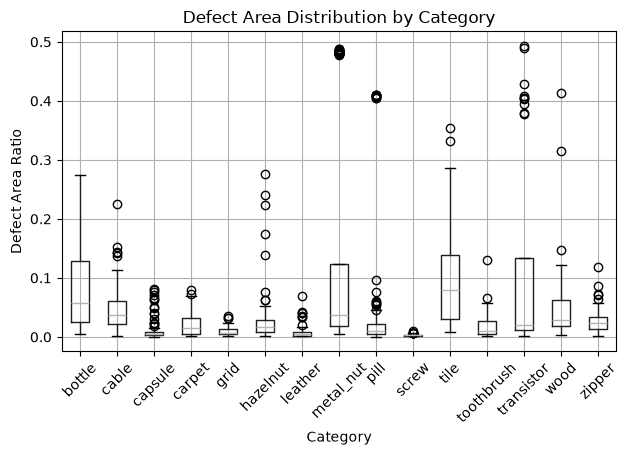

In [29]:
plt.figure(figsize=(12, 6))

defect_area_df.boxplot(
    column="defect_ratio",
    by="category",
    rot=45
)

plt.title("Defect Area Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Defect Area Ratio")

plt.tight_layout()
plt.show()

## 1.18 Check Image Color Channels

In [30]:
channel_info = []

for category in categories:

    image_path = next(
        (DATA_DIR / category / "train" / "good").glob("*.png")
    )

    with Image.open(image_path) as img:

        channel_info.append({
            "category": category,
            "mode": img.mode,
            "size": img.size
        })


pd.DataFrame(channel_info)

,category,mode,size
0,bottle,RGB,"(900, 900)"
1,cable,RGB,"(1024, 1024)"
2,capsule,RGB,"(1000, 1000)"
3,carpet,RGB,"(1024, 1024)"
4,grid,L,"(1024, 1024)"
5,hazelnut,RGB,"(1024, 1024)"
6,leather,RGB,"(1024, 1024)"
7,metal_nut,RGB,"(700, 700)"
8,pill,RGB,"(800, 800)"
9,screw,L,"(1024, 1024)"


## 1.19 EDA Summary

The exploratory analysis reveals several important characteristics of the MVTec AD
dataset:

1. The dataset contains 15 industrial object and texture categories.

2. Training data contains only defect-free (`good`) samples, making this an
   unsupervised / one-class anomaly detection problem rather than conventional
   supervised classification.

3. The test set contains both normal and anomalous images across multiple defect
   types.

4. Ground-truth segmentation masks are provided for defective test images,
   enabling both image-level anomaly detection and pixel-level anomaly
   localization.

5. Image resolutions vary across categories, meaning that a consistent resizing
   strategy will be required before model training.

6. Defects vary substantially in size. Some anomalies occupy only a small fraction
   of the image, suggesting that excessive image downsampling could remove
   important defect information.

7. The visual appearance of both products and anomalies varies significantly
   across categories, making feature representation an important component of the
   anomaly detection pipeline.

### Modeling Implications

Based on these observations, the next stage will focus on:

- defining a consistent image preprocessing pipeline,
- selecting an appropriate input resolution,
- preparing normal training images for anomaly-detection training,
- preserving ground-truth masks for localization evaluation,
- and designing the dataset loader for deep-learning models.

The project will evaluate both **image-level anomaly detection** and
**pixel-level anomaly localization**.